
# CrowdHuman → Deformable DETR: Stages 1–4

**Project goal:** build a Transformer-based human detector for crowded, safety-relevant scenes and understand the full data-to-model pipeline before training.

This notebook is intentionally both:

1. a **working reference** that runs on the real CrowdHuman data in this project, and  
2. a **shareable technical summary** explaining *what each stage does, why we do it, and how it works*.

## Pipeline covered here

```text
CrowdHuman annotations/images
        ↓
Stage 1 — Data understanding + QC
        ↓
Stage 2 — PyTorch Dataset abstraction
        ↓
Stage 3 — Deformable-DETR preprocessing
        ↓
Stage 4 — Transformer forward pass + losses
```

We deliberately **do not train the full model yet**. The goal is to prove that the complete input/output path is correct first.



## 0. Project-root setup

### Goal

Make the notebook work reliably whether VS Code/Jupyter starts in:

- the project root,
- `notebooks/`,
- or some other interactive working directory.

### Why

Relative paths in Python are interpreted from the **current working directory**, not from the notebook's file location. This is why code may work with **Run Python File** but fail with **Run Cell**.

The code below searches upward until it finds:

`data/manifests/crowdhuman_train.jsonl`

and then adds the project root to `sys.path`.


In [1]:

from pathlib import Path
import sys

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    candidates = [start] + list(start.parents)

    for candidate in candidates:
        manifest = candidate / "data" / "manifests" / "crowdhuman_train.jsonl"
        if manifest.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing "
        "data/manifests/crowdhuman_train.jsonl\n"
        f"Current working directory: {Path.cwd()}"
    )

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TRAIN_MANIFEST = PROJECT_ROOT / "data" / "manifests" / "crowdhuman_train.jsonl"
VAL_MANIFEST = PROJECT_ROOT / "data" / "manifests" / "crowdhuman_val.jsonl"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Train manifest exists:", TRAIN_MANIFEST.exists())
print("Val manifest exists:", VAL_MANIFEST.exists())


Current working directory: /data/users2/hrokham/robotsafe-detr/notebooks
Project root: /data/users2/hrokham/robotsafe-detr
Train manifest exists: True
Val manifest exists: True



# Stage 1 — Understand the real CrowdHuman data

## Goal

Verify what the dataset actually contains before introducing any model logic.

For this project, the main training target is the CrowdHuman **full-body box**:

```text
fbox = [x, y, width, height]
```

CrowdHuman also provides:

- `vbox`: visible-body box
- `hbox`: head box
- ignore/occlusion metadata

## Why this stage matters

Many object-detection failures come from data bugs rather than model bugs:

- interpreting `[x, y, w, h]` as `[x1, y1, x2, y2]`,
- training on ignored regions,
- incorrect image paths,
- invalid or out-of-bounds boxes,
- silently mismatching annotations and images.

The first principle is therefore:

> **Do not train until raw labels have been inspected numerically and visually.**


In [2]:

import json
import numpy as np
from collections import Counter

def load_jsonl(path):
    with open(path, "r") as f:
        return [json.loads(line) for line in f if line.strip()]

train_records = load_jsonl(TRAIN_MANIFEST)

print("Training images:", len(train_records))

persons_per_image = [len(r["annotations"]) for r in train_records]
ignored_per_image = [len(r["ignored_annotations"]) for r in train_records]

print("Mean usable persons/image:", np.mean(persons_per_image))
print("Median usable persons/image:", np.median(persons_per_image))
print("Max usable persons/image:", np.max(persons_per_image))
print("Mean ignored persons/image:", np.mean(ignored_per_image))

occlusion_counts = Counter()

for record in train_records:
    for ann in record["annotations"]:
        occlusion_counts[ann.get("occlusion")] += 1

print("\nOcclusion counts:")
print(occlusion_counts)


Training images: 15000
Mean usable persons/image: 22.637666666666668
Median usable persons/image: 16.0
Max usable persons/image: 377
Mean ignored persons/image: 0.8945333333333333

Occlusion counts:
Counter({1: 243879, 0: 95686})



## Inspect one real sample

We select a real image from the training manifest and compare the three CrowdHuman box types.

### What we want to verify

- `bbox_xywh` / `fbox` covers the estimated full person.
- `visible_bbox_xywh` covers only the visible region.
- `head_bbox_xywh` covers the head.
- ignored annotations are kept as metadata rather than mixed into the positive training targets.


In [3]:

from PIL import Image

sample_record = next(
    r for r in train_records
    if len(r["annotations"]) > 0
)

print("CrowdHuman ID:", sample_record["crowdhuman_id"])
print("Image path:", sample_record["image_path"])
print("Usable persons:", len(sample_record["annotations"]))
print("Ignored annotations:", len(sample_record["ignored_annotations"]))

from pathlib import Path

image_path = Path(sample_record["image_path"])

if not image_path.is_absolute():
    image_path = PROJECT_ROOT / image_path

print("Resolved image path:", image_path)
print("Exists:", image_path.exists())

assert image_path.exists(), (
    f"Image not found: {image_path}"
)

image = Image.open(image_path).convert("RGB")

print("Image size (W, H):", image.size)
print("First annotation:")
print(sample_record["annotations"][0])


CrowdHuman ID: 284193,faa9000f2678b5e
Image path: data/crowdhuman/Images/284193,faa9000f2678b5e.jpg
Usable persons: 7
Ignored annotations: 0
Resolved image path: /data/users2/hrokham/robotsafe-detr/data/crowdhuman/Images/284193,faa9000f2678b5e.jpg
Exists: True
Image size (W, H): (1024, 683)
First annotation:
{'bbox_xywh': [61.0, 123.0, 191.0, 453.0], 'visible_bbox_xywh': [62, 126, 154, 446], 'head_bbox_xywh': [123, 129, 63, 64], 'occlusion': 1, 'box_id': 0}


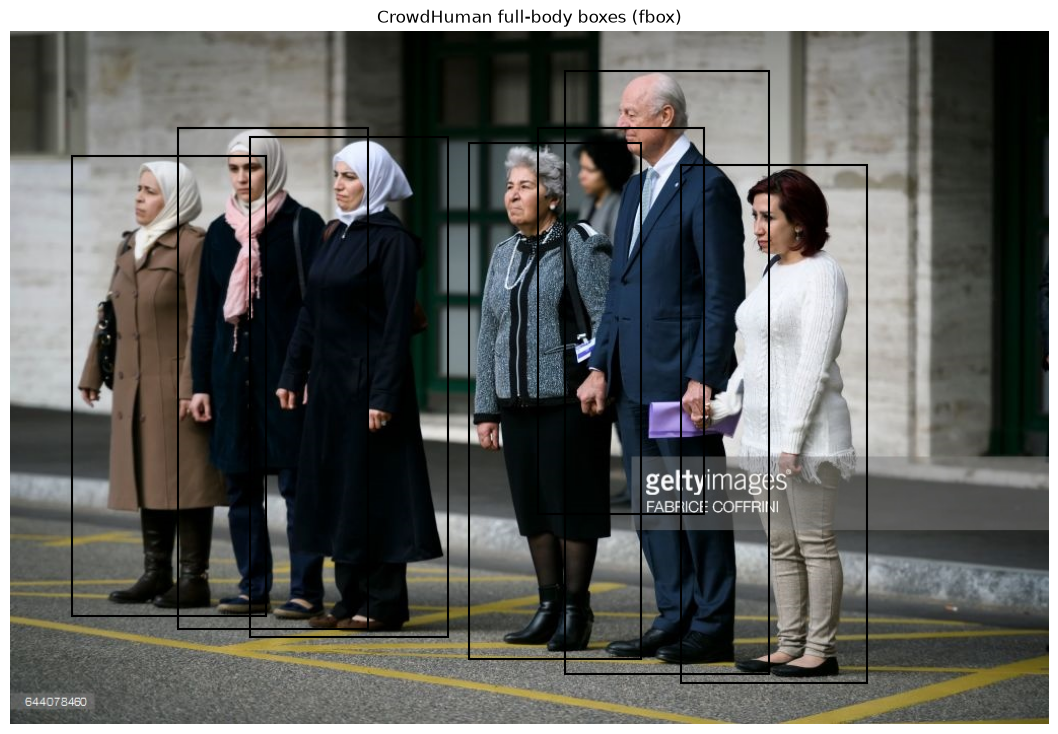

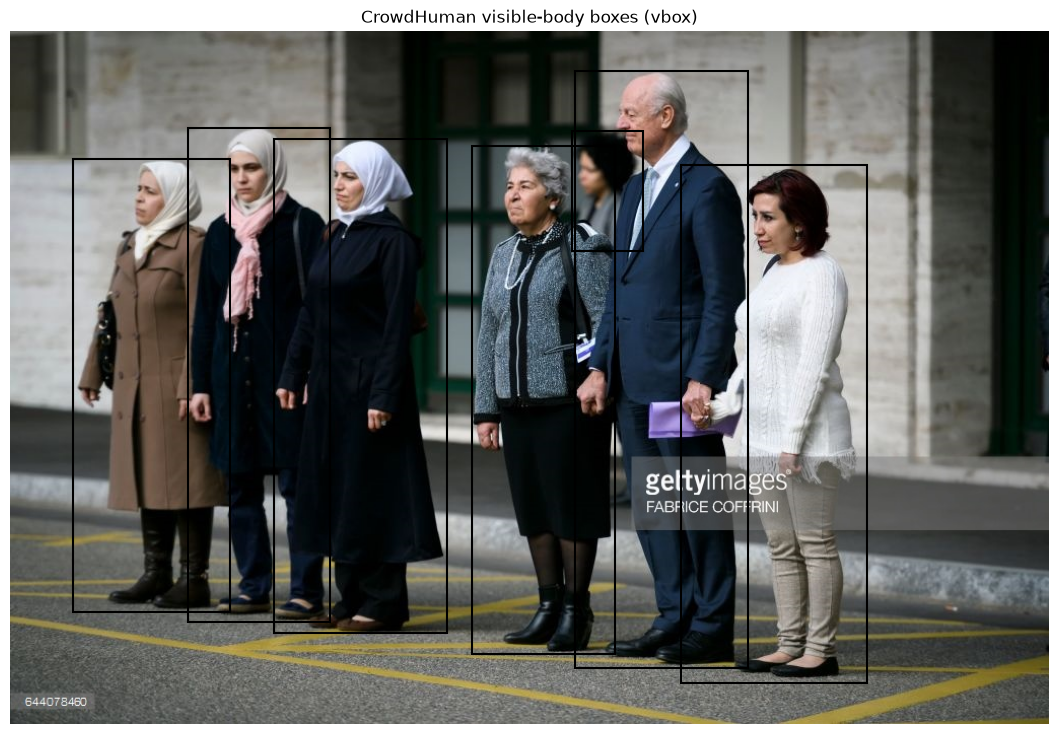

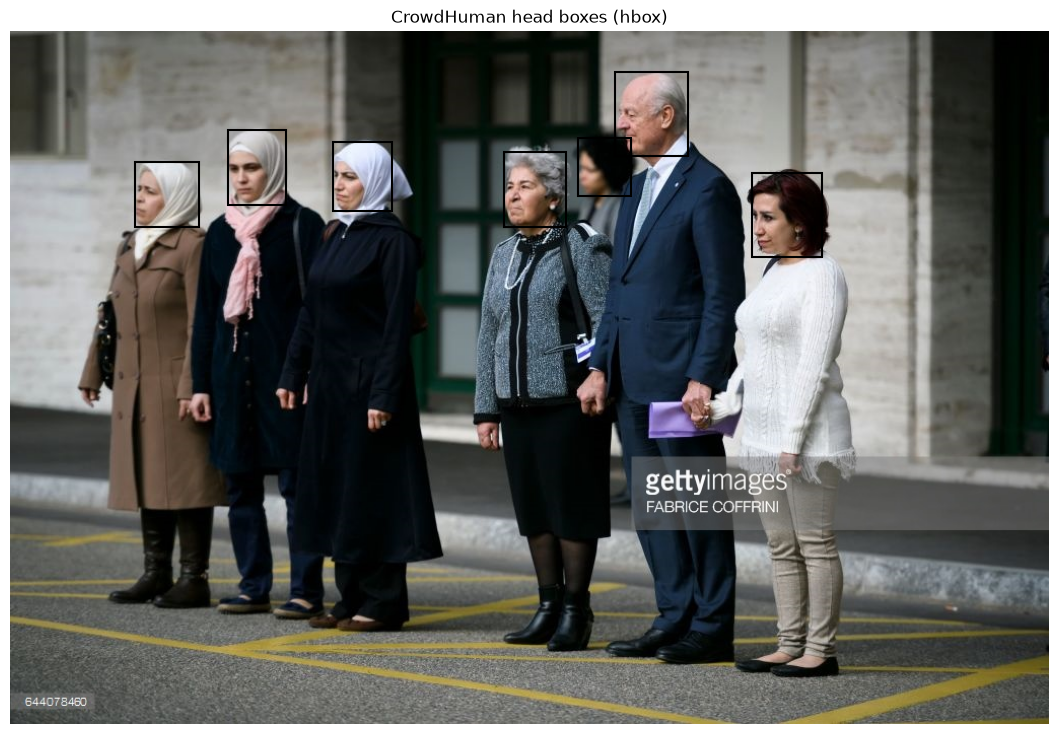

In [4]:

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def show_box_type(image, annotations, key, title, max_boxes=None):
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(image)

    anns = annotations if max_boxes is None else annotations[:max_boxes]

    for ann in anns:
        box = ann.get(key)
        if box is None:
            continue

        x, y, w, h = box
        rect = Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=1.5,
        )
        ax.add_patch(rect)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

show_box_type(
    image,
    sample_record["annotations"],
    "bbox_xywh",
    "CrowdHuman full-body boxes (fbox)"
)

show_box_type(
    image,
    sample_record["annotations"],
    "visible_bbox_xywh",
    "CrowdHuman visible-body boxes (vbox)"
)

show_box_type(
    image,
    sample_record["annotations"],
    "head_bbox_xywh",
    "CrowdHuman head boxes (hbox)"
)



### Stage 1 takeaway

At this point we trust the raw annotation geometry.

The box representation entering the detection pipeline is:

```text
[x, y, width, height] in original image pixels
```

This will later be transformed by the Deformable-DETR image processor into:

```text
[center_x, center_y, width, height] normalized to [0, 1]
```

For a safety-oriented detector, keeping the CrowdHuman metadata is useful because later evaluation should be sliced by:

- occlusion,
- person size,
- crowd density,
- visible fraction,
- ignored/ambiguous regions.



# Stage 2 — PyTorch Dataset abstraction

## Goal

Separate **dataset-specific I/O** from **model-specific preprocessing**.

The `Dataset` should only answer:

> "Given index *i*, what is the raw image and its raw annotations?"

It should **not** resize, normalize, pad, or convert boxes for DETR.

## Why

Keeping these responsibilities separate makes debugging much easier:

```text
CrowdHuman files
      ↓
Dataset
      ↓
raw PIL image + raw annotations
      ↓
model-specific processor
```

This also lets us reuse the same dataset with another detector later.


In [5]:

from src.dataset import CrowdHumanDataset

dataset = CrowdHumanDataset(TRAIN_MANIFEST)

print("Dataset size:", len(dataset))

sample = dataset[0]

print("Returned keys:", sample.keys())
print("Image size:", sample["image"].size)
print("Image ID:", sample["image_id"])
print("CrowdHuman ID:", sample["crowdhuman_id"])
print("Usable persons:", len(sample["annotations"]))
print("Ignored:", len(sample["ignored_annotations"]))


Dataset size: 15000
Returned keys: dict_keys(['image', 'image_id', 'crowdhuman_id', 'annotations', 'ignored_annotations', 'image_path'])
Image size: (1024, 683)
Image ID: 0
CrowdHuman ID: 284193,faa9000f2678b5e
Usable persons: 7
Ignored: 0



### Stage 2 takeaway

`CrowdHumanDataset` provides a clean abstraction over the file structure.

The important design choice is:

> **`__getitem__` returns the original PIL image and original annotations.**

No Transformer-specific logic lives in the dataset class.



# Stage 3 — Convert real CrowdHuman samples into Deformable-DETR inputs

## Goal

Transform the raw sample into the tensors expected by Deformable DETR.

The processor performs several operations consistently:

1. resize the image,
2. normalize RGB channels,
3. pad multiple images in a batch,
4. create a `pixel_mask`,
5. convert detection targets from pixel-space `xywh` into normalized `cxcywh`.

## Why use the processor?

The image and bounding boxes must undergo **exactly the same geometric transformation**.

If we resized the image ourselves but forgot to transform the boxes identically, training would silently become invalid.


In [6]:

from src.detr_data import (
    build_processor,
    make_coco_target,
    make_collate_fn,
)

processor = build_processor()

sample = next(
    dataset[i]
    for i in range(len(dataset))
    if len(dataset[i]["annotations"]) > 0
)

target = make_coco_target(sample)

print("Original image size:", sample["image"].size)
print("First raw CrowdHuman box:")
print(sample["annotations"][0]["bbox_xywh"])

print("\nFirst COCO-style annotation sent to processor:")
print(target["annotations"][0])

print("\nProcessor resize configuration:")
print(processor.size)


/data/users2/hrokham/anaconda3/envs/robotsafe/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original image size: (1024, 683)
First raw CrowdHuman box:
[61.0, 123.0, 191.0, 453.0]

First COCO-style annotation sent to processor:
{'image_id': 0, 'category_id': 0, 'bbox': [61.0, 123.0, 191.0, 453.0], 'area': 86523.0, 'iscrowd': 0}

Processor resize configuration:
SizeDict(height=None, width=None, longest_edge=1333, shortest_edge=800, max_height=None, max_width=None, min_pixels=None, max_pixels=None)


In [7]:

encoding = processor(
    images=sample["image"],
    annotations=target,
    return_tensors="pt",
)

print("Encoding keys:", encoding.keys())
print("pixel_values shape:", encoding["pixel_values"].shape)
print("pixel_mask shape:", encoding["pixel_mask"].shape)

labels = encoding["labels"][0]

print("\nLabel keys:", labels.keys())
print("Number of objects:", labels["boxes"].shape[0])
print("First 5 transformed boxes:")
print(labels["boxes"][:5])

print("\nFirst 5 class labels:")
print(labels["class_labels"][:5])


Encoding keys: KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[-0.3712, -0.3712, -0.3712,  ..., -2.1179, -2.1179, -2.1179],
          [-0.4054, -0.4054, -0.4054,  ..., -2.1179, -2.1179, -2.1179],
          [-0.5596, -0.5596, -0.5596,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-1.3302, -1.2959, -1.2274,  ..., -0.4054, -0.4054, -0.4054],
          [-1.2788, -1.2788, -1.2617,  ..., -0.3883, -0.3883, -0.3883],
          [-1.2959, -1.3302, -1.3302,  ..., -0.3541, -0.3541, -0.3541]],

         [[-0.2325, -0.2325, -0.2325,  ..., -2.0007, -2.0007, -2.0007],
          [-0.2675, -0.2675, -0.2675,  ..., -2.0007, -2.0007, -2.0007],
          [-0.4251, -0.4251, -0.4251,  ..., -2.0007, -2.0007, -2.0007],
          ...,
          [-1.1604, -1.1254, -1.0553, 


## Box representation transformation

For one original CrowdHuman box:

```text
[x, y, width, height]  (pixels)
```

we expect Deformable DETR to receive:

```text
[cx, cy, width, height]  (normalized)
```

with:

\[
c_x = \frac{x + w/2}{W}
\]

\[
c_y = \frac{y + h/2}{H}
\]

\[
w_n = \frac{w}{W}, \quad h_n = \frac{h}{H}
\]

The next cell verifies this numerically using a real CrowdHuman annotation.


In [8]:

import torch

W, H = sample["image"].size
x, y, w, h = sample["annotations"][0]["bbox_xywh"]

expected_box = torch.tensor(
    [
        (x + w / 2) / W,
        (y + h / 2) / H,
        w / W,
        h / H,
    ],
    dtype=torch.float32,
)

actual_box = labels["boxes"][0].cpu()

print("Expected normalized box:")
print(expected_box)

print("\nProcessor-produced box:")
print(actual_box)

print("\nAbsolute difference:")
print(torch.abs(expected_box - actual_box))

print(
    "\nNote: if the original box extends outside the image, "
    "the processor may clip it, so a larger difference can be valid."
)


Expected normalized box:
tensor([0.1528, 0.5117, 0.1865, 0.6633])

Processor-produced box:
tensor([0.1528, 0.5117, 0.1865, 0.6633])

Absolute difference:
tensor([0.0000e+00, 5.9605e-08, 0.0000e+00, 5.9605e-08])

Note: if the original box extends outside the image, the processor may clip it, so a larger difference can be valid.



## Batch processing and `pixel_mask`

Images have different dimensions.

A neural-network batch, however, must be rectangular:

```text
[B, C, H, W]
```

Therefore the processor pads smaller images.

`pixel_mask` tells the Transformer which spatial positions contain:

```text
1 = real image
0 = padding
```

This prevents attention from treating padded regions as real visual content.


In [9]:

from torch.utils.data import DataLoader

collate_fn = make_collate_fn(processor)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,  # keep 0 while debugging
    collate_fn=collate_fn,
)

batch = next(iter(loader))

print("pixel_values:", batch["pixel_values"].shape)
print("pixel_mask:", batch["pixel_mask"].shape)
print("number of target dictionaries:", len(batch["labels"]))

for i, target_i in enumerate(batch["labels"]):
    print(
        f"Image {i}:",
        "objects =", target_i["boxes"].shape[0],
        "| boxes shape =", tuple(target_i["boxes"].shape),
        "| class_labels shape =", tuple(target_i["class_labels"].shape),
    )

for i in range(batch["pixel_mask"].shape[0]):
    ratio = batch["pixel_mask"][i].float().mean().item()
    print(f"Image {i} real-pixel ratio: {ratio:.4f}")


pixel_values: torch.Size([2, 3, 800, 1199])
pixel_mask: torch.Size([2, 800, 1199])
number of target dictionaries: 2
Image 0: objects = 7 | boxes shape = (7, 4) | class_labels shape = (7,)
Image 1: objects = 7 | boxes shape = (7, 4) | class_labels shape = (7,)
Image 0 real-pixel ratio: 1.0000
Image 1 real-pixel ratio: 0.8340



### Stage 3 takeaway

We have now validated the entire model-input contract:

```text
Raw CrowdHuman image
        ↓
DeformableDetrImageProcessor
        ↓
pixel_values  [B, 3, H, W]
pixel_mask    [B, H, W]
labels        list[dict]
```

and verified that the target boxes are normalized `cxcywh`.

This is the last checkpoint before introducing the Transformer itself.



# Stage 4 — First Deformable-DETR forward pass

## Goal

Run a real CrowdHuman batch through the pretrained Deformable DETR architecture and inspect:

- model configuration,
- object-query output shapes,
- class logits,
- predicted boxes,
- decoder hidden representations,
- training loss components.

## Why no training yet?

Before spending GPU time, we want to prove that:

```text
real data
→ correct processor outputs
→ model forward pass
→ finite losses
```

works end to end.

A valid forward pass is effectively an integration test for the whole modeling pipeline.


In [10]:

from transformers import DeformableDetrForObjectDetection

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

id2label = {0: "person"}
label2id = {"person": 0}

MODEL_ID = "SenseTime/deformable-detr"

model = DeformableDetrForObjectDetection.from_pretrained(
    MODEL_ID,
    num_labels=1,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("\nModel configuration")
print("num_queries:", model.config.num_queries)
print("d_model:", model.config.d_model)
print("encoder_layers:", model.config.encoder_layers)
print("decoder_layers:", model.config.decoder_layers)
print("num_labels:", model.config.num_labels)


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `91`.


Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 2622.11it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.bac


Model configuration
num_queries: 300
d_model: 256
encoder_layers: 6
decoder_layers: 6
num_labels: 1



### Why `ignore_mismatched_sizes=True`?

The checkpoint was pretrained on COCO and therefore had a multi-class classification head.

Our task has only:

```text
person
```

so the classification head has a different shape.

We reuse the pretrained:

- ResNet backbone,
- Transformer encoder,
- Transformer decoder,
- box-regression machinery,

while creating a new single-class detection head.

This is transfer learning.

> Because the new classification head is not trained yet, **do not interpret the prediction quality at this stage**.


In [11]:

# Use a fresh batch of size 1 for the first model inspection.
single_loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

single_batch = next(iter(single_loader))

pixel_values = single_batch["pixel_values"].to(device)
pixel_mask = single_batch["pixel_mask"].to(device)

print("Input pixel_values:", pixel_values.shape)
print("Input pixel_mask:", pixel_mask.shape)
print(
    "Ground-truth objects:",
    single_batch["labels"][0]["boxes"].shape[0]
)

model.eval()

with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        pixel_mask=pixel_mask,
    )

print("\nModel outputs")
print("logits:", outputs.logits.shape)
print("pred_boxes:", outputs.pred_boxes.shape)

if outputs.last_hidden_state is not None:
    print("last_hidden_state:", outputs.last_hidden_state.shape)


Input pixel_values: torch.Size([1, 3, 800, 1199])
Input pixel_mask: torch.Size([1, 800, 1199])
Ground-truth objects: 7

Model outputs
logits: torch.Size([1, 300, 1])
pred_boxes: torch.Size([1, 300, 4])
last_hidden_state: torch.Size([1, 300, 256])



## How to interpret the output dimensions

Conceptually:

```text
logits:
[B, Q, C+1]

pred_boxes:
[B, Q, 4]
```

where:

- `B` = batch size
- `Q` = number of object queries
- `C` = foreground object classes

For this project:

```text
C = 1  → person
```

Each object query produces:

```text
query embedding
      ├── classification prediction
      └── bounding-box prediction
```

The predicted box is normalized:

```text
[cx, cy, width, height]
```

Object queries should be understood as **candidate object slots**, not fixed semantic categories.


In [12]:

query_index = 0

print(f"Query {query_index} raw logits:")
print(outputs.logits[0, query_index])

print(f"\nQuery {query_index} normalized predicted box:")
print(outputs.pred_boxes[0, query_index])

probs = outputs.logits.softmax(dim=-1)

print(f"\nQuery {query_index} probabilities:")
print(probs[0, query_index])


Query 0 raw logits:
tensor([0.0807], device='cuda:0')

Query 0 normalized predicted box:
tensor([0.9199, 0.3820, 0.1559, 0.7788], device='cuda:0')

Query 0 probabilities:
tensor([1.], device='cuda:0')



## Decoder hidden state

A typical decoder output can be interpreted as:

```text
[B, Q, d_model]
```

For each image:

- every object query ends as a `d_model`-dimensional representation,
- a classification head maps that vector to semantic scores,
- a box MLP maps that vector to `cxcywh`.

So the decoder output is the learned representation of each candidate object hypothesis.



## Compute the training loss on a real CrowdHuman sample

Passing ground-truth `labels` changes the model from pure inference into loss computation.

Conceptually, the objective combines:

```text
classification loss
+
L1 box regression loss
+
generalized-IoU loss
```

Before these losses can be computed, predicted queries must be matched to real people.

That assignment problem is **Hungarian matching**, which will be Stage 5.


In [13]:

labels_on_device = []

for target in single_batch["labels"]:
    moved = {}
    for key, value in target.items():
        moved[key] = value.to(device) if torch.is_tensor(value) else value
    labels_on_device.append(moved)

with torch.no_grad():
    outputs_with_loss = model(
        pixel_values=pixel_values,
        pixel_mask=pixel_mask,
        labels=labels_on_device,
    )

print("Total loss:", outputs_with_loss.loss.item())

print("\nLoss components:")
for name, value in outputs_with_loss.loss_dict.items():
    print(f"{name:24s} {value.item():.6f}")


Total loss: 8.039152145385742

Loss components:
loss_ce                  7.139968
loss_bbox                0.075295
loss_giou                0.261355
cardinality_error        237.000000



# Stages 1–4 summary

## Stage 1 — Data understanding / QC

**Goal:** prove that the raw CrowdHuman images and annotations are correct.

**Why:** bad coordinate assumptions can invalidate the entire experiment.

**Real-data checks performed:**

- dataset statistics,
- usable vs. ignored annotations,
- full-body boxes,
- visible-body boxes,
- head boxes,
- occlusion metadata.

---

## Stage 2 — PyTorch Dataset

**Goal:** create a clean abstraction over CrowdHuman files.

**Why:** dataset-specific loading should be separate from model-specific preprocessing.

```text
index
  ↓
CrowdHumanDataset
  ↓
PIL image + annotations + metadata
```

---

## Stage 3 — Deformable-DETR preprocessing

**Goal:** produce the exact tensor/target representation the Transformer expects.

**Why:** image resize/padding and box transforms must remain geometrically consistent.

```text
CrowdHuman fbox
[x, y, w, h] pixels
       ↓
Image processor
       ↓
DETR target
[cx, cy, w, h] normalized
```

The processor also creates:

```text
pixel_values
pixel_mask
```

for batched Transformer input.

---

## Stage 4 — Model forward pass

**Goal:** verify the complete data-to-model pipeline before training.

```text
CrowdHuman image
      ↓
ResNet-50 backbone
      ↓
multi-scale feature maps
      ↓
Deformable Transformer encoder
      ↓
object queries + decoder
      ↓
classification logits + boxes
```

We also confirmed that real ground truth produces finite model losses.

---

# Why this workflow matters

The main engineering principle is:

> **Make every transformation observable before optimizing anything.**

This makes later failures easier to localize:

```text
data bug?
annotation bug?
processor bug?
model/configuration bug?
optimization problem?
evaluation problem?
```

rather than treating the detector as one opaque system.

---

# Next stage

**Stage 5 — Hungarian matching**

We will construct a tiny prediction/ground-truth example and explicitly build the assignment cost matrix using:

- class cost,
- L1 box cost,
- generalized-IoU cost,

then solve the one-to-one assignment ourselves before relying on the library implementation.



# Suggested interview framing

This notebook demonstrates more than "fine-tuning a pretrained Transformer."

The workflow shows:

1. **data management** — explicit manifests, ignore handling, metadata retention;
2. **data validation** — visual and numerical QC before training;
3. **network understanding** — object queries, decoder representations, box heads;
4. **reproducible preprocessing** — one processor owns image and annotation transforms;
5. **integration validation** — real data through the complete forward/loss path;
6. **research discipline** — no large training run until the small pipeline is proven correct.

Later notebooks can extend this into:

- Stage 5: Hungarian matching
- Stage 6: 50-image overfit + training loop
- Stage 7: hyperparameter search
- Stage 8: standard + safety-oriented evaluation
- Stage 9: ONNX/TensorRT deployment
- Stage 10: shadow-mode / online validation
